In [5]:
!pip install ipywidgets widgetsnbextension

import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2')
model.eval()
print("Ready")

  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)

   ------------- -------------------------- 1/3 [jupyterlab_widgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   ---------------------------------------- 3/3 [ipywidgets]




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\UAE LAPTOP BAZAR\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


Ready


In [6]:
def generate(prompt, max_new_tokens=20):
    inputs = tokenizer(prompt, return_tensors='pt')
    with torch.no_grad():
        output = model.generate(
            inputs['input_ids'],
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    return tokenizer.decode(output[0], skip_special_tokens=True)

pairs = [
    ("The capital of France is Paris, which",
     "The capital of France is Berlin, which"),
    ("Penicillin, discovered by Alexander Fleming,",
     "Penicillin, discovered by Louis Pasteur,"),
    ("The Earth orbits the Sun, completing",
     "The Earth orbits the Moon, completing"),
    ("Shakespeare, born in Stratford-upon-Avon,",
     "Shakespeare, born in New York,"),
    ("Water boils at 100 degrees Celsius, which means",
     "Water boils at 20 degrees Celsius, which means"),
]

results = []
for correct_prefix, wrong_prefix in pairs:
    correct_out = generate(correct_prefix)
    wrong_out = generate(wrong_prefix)
    results.append({
        'Correct Prefix': correct_prefix,
        'Correct Continuation': correct_out[len(correct_prefix):].strip(),
        'Wrong Prefix': wrong_prefix,
        'Cascaded Output': wrong_out[len(wrong_prefix):].strip(),
    })
    print(f"CORRECT: {correct_out}")
    print(f"WRONG:   {wrong_out}")
    print("---")

df = pd.DataFrame(results)
df.to_csv('mechanism3_outputs.csv', index=False)
print("Saved: mechanism3_outputs.csv")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


CORRECT: The capital of France is Paris, which is home to the French capital's largest city, the Louvre.

The French capital is
WRONG:   The capital of France is Berlin, which is home to the world's largest concentration of German Jews.

The city is home to the
---
CORRECT: Penicillin, discovered by Alexander Fleming, was used to treat tuberculosis in the 19th century.

The drug was used to treat tuberculosis
WRONG:   Penicillin, discovered by Louis Pasteur, was used to treat tuberculosis in the United States in the 1930s.

The drug was used
---
CORRECT: The Earth orbits the Sun, completing its orbit around the Sun. The Earth orbits the Sun at a distance of about 1,000 light
WRONG:   The Earth orbits the Moon, completing its orbit around the Sun. The Moon is the only planet in the solar system that orbits the Sun
---
CORRECT: Shakespeare, born in Stratford-upon-Avon, England, in 1843, is a poet, playwright, and dramatist. He has
WRONG:   Shakespeare, born in New York, died in London in

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


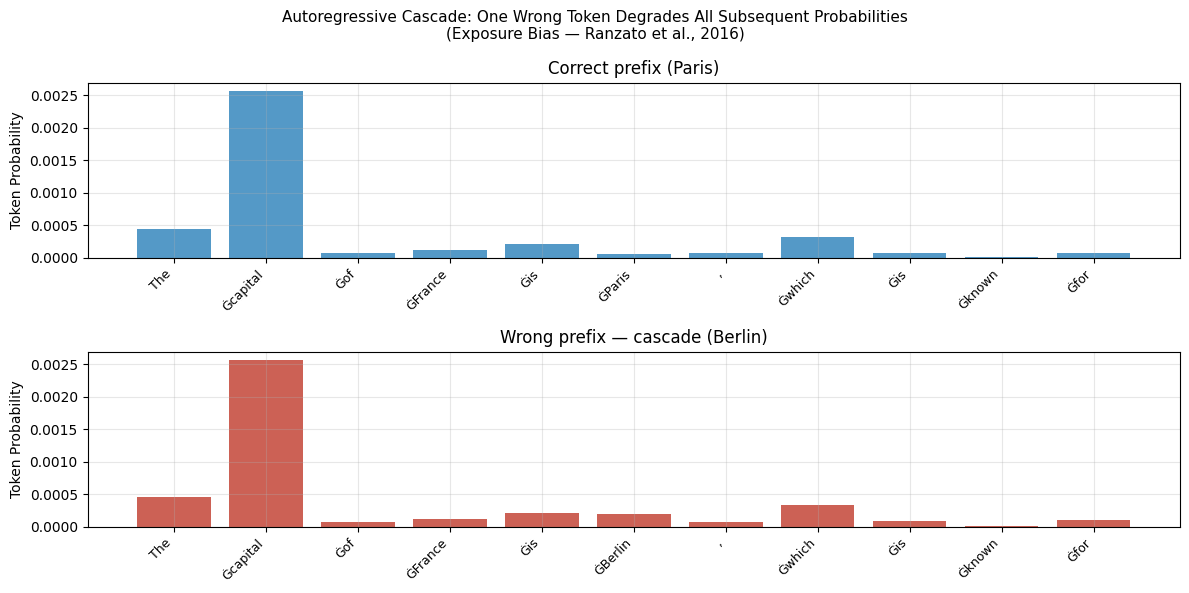

Saved: mechanism3_cascade.pdf


In [7]:
def token_level_probs(prompt):
    inputs = tokenizer(prompt, return_tensors='pt')
    with torch.no_grad():
        outputs = model(**inputs, labels=inputs['input_ids'])
        logits = outputs.logits
    probs = torch.softmax(logits[0], dim=-1)
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    token_probs = [probs[i, inputs['input_ids'][0][i]].item() 
                   for i in range(len(tokens))]
    return tokens, token_probs

correct = "The capital of France is Paris, which is known for"
wrong   = "The capital of France is Berlin, which is known for"

t1, p1 = token_level_probs(correct)
t2, p2 = token_level_probs(wrong)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
for ax, tokens, probs, label, color in zip(
    axes, [t1,t2], [p1,p2],
    ['Correct prefix (Paris)','Wrong prefix — cascade (Berlin)'],
    ['#2980B9','#C0392B']
):
    ax.bar(range(len(tokens)), probs, color=color, alpha=0.8)
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Token Probability')
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

plt.suptitle('Autoregressive Cascade: One Wrong Token Degrades All Subsequent Probabilities\n(Exposure Bias — Ranzato et al., 2016)', fontsize=11)
plt.tight_layout()
plt.savefig('mechanism3_cascade.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: mechanism3_cascade.pdf")